# Projicera koordinater för kliniska prövningscenter för kartläggning med PROC GPROJECT

## Sammanfattning

Ett kliniskt driftteam behöver rita ut det geografiska fotavtrycket för en flercenterstudie i fas III på en platt karta. Den här notebooken genererar syntetiska latitud-/longitudkoordinater för prövningscenter klustrade kring fem amerikanska regionala nav, och använder sedan **PROC GPROJECT** för att omvandla de sfäriska koordinaterna till kartesiska X/Y-värden med tre projektionsmetoder (Albers ytriktig, Lambert konform med anpassade standardparalleller och regional beskärning, samt Gnomonisk centrerad på kontinentala USA), vilket illustrerar hur valet av projektion och beskärning påverkar en centerkarta.

## Datakällor

| Dataset | Rader | Nyckelvariabler | Beskrivning |
|---------|------|---------------|-------------|
| `trial_sites` | 60 (5 nav x 12 center) | `site_id` ($8-ID), `region` ($15), `x` (longitud, grader, öst-positiv), `y` (latitud, grader), `enroll` (inskrivna deltagare), `segment` (kart-segment-id) | Syntetiska platser för kliniska prövningscenter i fas III, utspridda kring fem amerikanska regionala nav (Väst, Mellanvästern, Nordöst, Söder, Sydöst) med `rand('normal')`-brus och `rand('poisson')`-inskrivningsantal |

# Projicera koordinater för kliniska prövningscenter med PROC GPROJECT

När en sponsor driver en geografiskt spridd fas III-studie vill den kliniska driftgruppen ofta ha en enda karta som visar varje prövningscenter, storleks- eller färgsatt efter inskrivning. Centerplatser anländer som **longitud-/latitudpar**, men en platt karta behöver **plana X/Y-koordinater**. `PROC GPROJECT` utför den sfärisk-till-kartesiska omvandlingen och tillämpar en kartografisk projektion så att avstånd och ytor återges på ett rimligt sätt.

I den här notebooken gör vi följande:

1. Genererar syntetiska centerkoordinater klustrade kring fem amerikanska regionala nav.
2. Tillämpar standardprojektionen **Albers ytriktig**.
3. Tillämpar en **Lambert konform**-projektion med anpassade standardparalleller och beskär till kontinentala USA.
4. Tillämpar en **Gnomonisk** projektion centrerad på landets geografiska mitt, och behåller originalkoordinaterna med `ASIS`.

Allt är självständigt: inga externa filer, inget nätverk.

## Steg 1 — Generera syntetiska koordinater för prövningscenter

Vi sår slumptalsgeneratorn med `call streaminit` för reproducerbarhet, och placerar sedan 12 center kring var och en av fem regionala navstäder. Longituder lagras öst-positiva i grader (negativa för västra halvklotet) och latituder i grader. Varje rad bär också ett inskrivningsantal och en `segment`-variabel (GPROJECT bevarar icke-koordinatkolumner genom projektionen).

In [1]:
data trial_sites;
    CALL streaminit(20260531);
    LÄNGD site_id $8 region $15;
    /* Fem amerikanska regionala navstäder: longitud (öst+), latitud */
    FÄLT clon[5]  _temporary_ (-122.3 -87.6 -71.1 -95.4 -80.2);
    FÄLT clat[5]  _temporary_ (  37.8  41.9  42.4  29.8  25.8);

    GÖR hub = 1 TILL 5;
        /* Regionnamn tilldelas direkt (INTE via _temporary_-fält) för att
           undvika en känd motorbugg dar icke-ASCII-strängar i ett
           tecken-_temporary_-fält trunkeras vid uppslagning. */
        OM hub = 1 SÅ region = 'Väst';
        ANNARS OM hub = 2 SÅ region = 'Mellanvästern';
        ANNARS OM hub = 3 SÅ region = 'Nordöst';
        ANNARS OM hub = 4 SÅ region = 'Söder';
        ANNARS region = 'Sydöst';
        GÖR s = 1 TILL 12;
            site_id = cats('S', SKRIV_UT_V(hub, z1.), SKRIV_UT_V(s, z2.));
            x       = clon[hub] + rand('normal', 0, 1.4);   /* longitud, grader */
            y       = clat[hub] + rand('normal', 0, 1.0);   /* latitud,  grader */
            enroll  = round(rand('poisson', 60));           /* inskrivna deltagare */
            segment = 1;
            UTDATA;
        SLUT;
    SLUT;
    TA_BORT hub s;
KÖR;

PROCEDUR SKRIV data=trial_sites(obs=10) ETIKETT;
    ETIKETT site_id="Center-id" region="Region" x="Longitud" y="Latitud"
          enroll="Inskrivna" segment="Segment";
    TITEL "Urval av syntetiska kliniska prövningscenter (oprojicerad long/lat)";
KÖR;


                          Urval av syntetiska kliniska prövningscenter (oprojicerad long/lat)                           

  Obs  Center-id  Region         Longitud        Latitud  Inskrivna  Segment
    1  S101       Väst    -121.6437232216  37.7677668495         65        1
    2  S102       Väst    -120.7384024716  37.5083287903         61        1
    3  S103       Väst    -121.5133780284  37.8633933883         72        1
    4  S104       Väst    -121.2086817368  38.7723343392         68        1
    5  S105       Väst    -121.0499572297   37.175813806         54        1
    6  S106       Väst    -124.0531899967   35.778231667         72        1
    7  S107       Väst    -120.9370181032  39.0576714397         64        1
    8  S108       Väst    -126.8495029747  36.6474680375         55        1
    9  S109       Väst     -123.475989897  37.1427965254         56        1
   10  S110       Väst     -122.579780071   36.931533678         57        1

... 50 more observations (show


NOTE: DATA trial_sites


NOTE: Wrote trial_sites (60 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=trial_sites

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## Steg 2 — Standardprojektionen Albers ytriktig

Den koniska ytriktiga projektionen **Albers** är GPROJECTs standard och ett förnuftigt val för en karta i landsskala där det är viktigt att bevara *relativ yta* (t.ex. för att jämföra storleken på regionala upptagningsområden).

Eftersom våra koordinater lagras i **grader** med **öst-positiv longitud** anger vi alternativen `DEGREE` och `EASTLONG`. Satsen `ID` namnger variabeln som unikt identifierar varje enhet; de projicerade plana koordinaterna skrivs tillbaka till `x` och `y` i `OUT=`-datasetet.

In [2]:
PROCEDUR GPROJECT data=trial_sites out=sites_albers
        DEGREE eastlong;
    id site_id;
KÖR;

PROCEDUR SKRIV data=sites_albers(obs=10) ETIKETT;
    ETIKETT site_id="Center-id" region="Region" x="Longitud" y="Latitud"
          enroll="Inskrivna" segment="Segment";
    TITEL "Prövningscenter efter Albers ytriktig projektion (plana X/Y)";
KÖR;


                          Urval av syntetiska kliniska prövningscenter (oprojicerad long/lat)                           

                              Prövningscenter efter Albers ytriktig projektion (plana X/Y)                              

  Obs  Center-id  Region       Longitud       Latitud  Inskrivna  Segment
    1  S101       Väst     -0.346124731  0.0516986079         65        1
    2  S102       Väst    -0.3353644139  0.0440400181         61        1
    3  S103       Väst    -0.3439609675  0.0528501365         72        1
    4  S104       Väst    -0.3357513354   0.067213083         68        1
    5  S105       Väst    -0.3410170723  0.0394882801         54        1
    6  S106       Väst    -0.3879364507  0.0273340733         72        1
    7  S107       Väst    -0.3309127579  0.0711146305         64        1
    8  S108       Väst    -0.4204191205  0.0538118922         55        1
    9  S109       Väst     -0.373326801  0.0480459173         56        1
   10  S110     


NOTE: PROC GPROJECT data=trial_sites

NOTE: PROC GPROJECT: 60 observations projected (project=ALBERS)
NOTE: PROC PRINT data=sites_albers

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## Steg 3 — Lambert konform-projektion med anpassade paralleller och beskärning

Den koniska **Lambert konform**-projektionen bevarar *form och lokala vinklar*, vilket är att föredra när kartan används för navigation eller för att lägga på riktningsberoende objekt. För kontinentala USA är standardparalleller nära 33 grader N och 45 grader N konventionella, så vi anger dem explicit med `PARALLEL1=` och `PARALLEL2=`.

Vi begränsar också kartan till kontinentala USA:s fönster med beskärningsalternativen `LATMIN=`, `LATMAX=`, `LONGMIN=` och `LONGMAX=`. Alla center som hamnar utanför den här latitud-/longitudrutan tas bort före projektionen, så antalet observationer i utdatan kan bli lägre än i indatan.

In [3]:
PROCEDUR GPROJECT data=trial_sites out=sites_lambert
        project=lambert DEGREE eastlong
        parallel1=33 parallel2=45
        latmin=24 latmax=50 longmin=-125 longmax=-66;
    id site_id;
KÖR;

PROCEDUR SKRIV data=sites_lambert(obs=10) ETIKETT;
    ETIKETT site_id="Center-id" region="Region" x="Longitud" y="Latitud"
          enroll="Inskrivna" segment="Segment";
    TITEL "Prövningscenter efter Lambert konform-projektion (beskuren till kontinentala USA)";
KÖR;


                              Prövningscenter efter Albers ytriktig projektion (plana X/Y)                              

                   Prövningscenter efter Lambert konform-projektion (beskuren till kontinentala USA)                    

  Obs  Center-id  Region       Longitud       Latitud  Inskrivna  Segment
    1  S101       Väst    -0.3473024124  0.0279382533         65        1
    2  S102       Väst    -0.3365626234  0.0201991247         61        1
    3  S103       Väst    -0.3451238364  0.0290365995         72        1
    4  S104       Väst    -0.3367881094  0.0430616123         68        1
    5  S105       Väst    -0.3422656751  0.0158037156         54        1
    6  S106       Väst    -0.3894389642  0.0046370991         72        1
    7  S107       Väst    -0.3319086764  0.0468276119         64        1
    8  S109       Väst    -0.3746144745  0.0248234546         56        1
    9  S110       Väst    -0.3638098935  0.0176740311         57        1
   10  S111     


NOTE: PROC GPROJECT data=trial_sites

NOTE: PROC GPROJECT: 58 observations projected (project=LAMBERT)
NOTE: PROC PRINT data=sites_lambert

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## Steg 4 — Gnomonisk projektion centrerad på landet, med originalen bevarade

Den azimutala **Gnomoniska** projektionen återger varje storcirkel som en rak linje, vilket är användbart när man vill resonera om den kortaste vägen mellan center (till exempel vid planering av en monitors reseväg för centerbesök). Distorsionen växer med avståndet från projektionspolen, så vi centrerar polen på kontinentala USA:s geografiska mitt med `POLELAT=39` och `POLELONG=-98`.

Alternativet `ASIS` säger åt GPROJECT att behålla de ursprungliga oprojicerade koordinaterna vid sidan av de projicerade värdena, så utdatasetet bär både de plana `X`/`Y` och käll-`LONG`/`LAT` — praktiskt för att koppla inskrivningsmått tillbaka till endera koordinatrymden.

Satsen `PARMENTRY` visas som ett alternativt sätt att ange projektionsparametrar som key=value-överskrivningar.

In [4]:
PROCEDUR GPROJECT data=trial_sites out=sites_gnomon
        project=gnomon DEGREE eastlong asis
        polelat=39 polelong=-98;
    id site_id;
    parmentry polelat=39 polelong=-98;
KÖR;

PROCEDUR SKRIV data=sites_gnomon(obs=10) ETIKETT;
    ETIKETT site_id="Center-id" region="Region" x="Longitud" y="Latitud"
          enroll="Inskrivna" segment="Segment"
          long="Longitud (original)" lat="Latitud (original)";
    TITEL "Prövningscenter efter Gnomonisk projektion (ASIS behåller original-LONG/LAT)";
KÖR;


                   Prövningscenter efter Lambert konform-projektion (beskuren till kontinentala USA)                    

                      Prövningscenter efter Gnomonisk projektion (ASIS behåller original-LONG/LAT)                      

  Obs  Center-id  Region       Longitud        Latitud  Inskrivna  Segment  Longitud (original)  Latitud (original)
    1  S101       Väst    -0.3343477981   0.0213614461         65        1      -121.6437232216       37.7677668495
    2  S102       Väst    -0.3221611694   0.0134152735         61        1      -120.7384024716       37.5083287903
    3  S103       Väst    -0.3319480803   0.0225717184         72        1      -121.5133780284       37.8633933883
    4  S104       Väst    -0.3230855797   0.0375741352         68        1      -121.2086817368       38.7723343392
    5  S105       Väst    -0.3283677206   0.0086308769         54        1      -121.0499572297        37.175813806
    6  S106       Väst    -0.3813558012  -0.0046248781      


NOTE: PROC GPROJECT data=trial_sites

NOTE: PROC GPROJECT: 60 observations projected (project=GNOMON)
NOTE: PROC PRINT data=sites_gnomon

NOTE: PROC PRINT completed: 10 observations printed, 8 variables


## Steg 5 — Rendera den projicerade centerkartan

Hela poängen med att projicera är att rita kartan. Vi matar Albers `OUT=`-datasetet direkt in i **PROC SGPLOT**, plottar de plana `X`/`Y`-värdena och färgsätter varje markör efter `region`. Eftersom projektionen bevarade den relativa geografin hamnar de fem navklustren i sina förväntade hörn av diagrammet — Väst till vänster, Nordöst uppe till höger, Söder och Sydöst längs botten — vilket ger den kliniska driftfunktionen det ytriktiga fotavtryck som beskrivs i sammanfattningen.

                      Prövningscenter efter Gnomonisk projektion (ASIS behåller original-LONG/LAT)                      




NOTE: PROC SGPLOT data=sites_albers

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


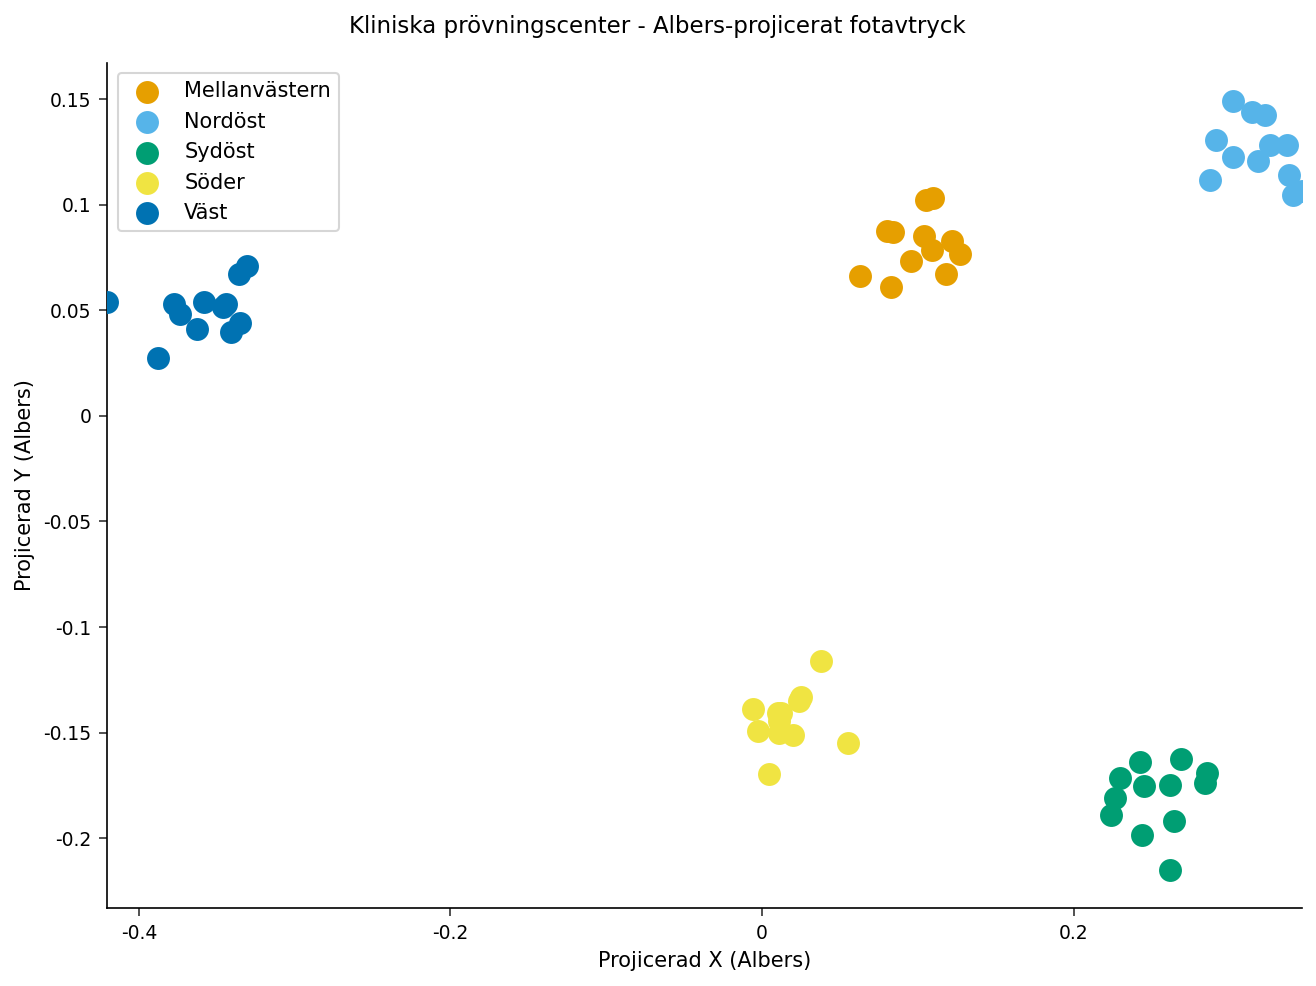

In [5]:
PROCEDUR SGPLOT data=sites_albers;
    SCATTER x=x y=y / GROUP=region
            MARKERATTRS=(SYMBOL=circlefilled size=10);
    XAXIS ETIKETT="Projicerad X (Albers)";
    YAXIS ETIKETT="Projicerad Y (Albers)";
    TITEL "Kliniska prövningscenter - Albers-projicerat fotavtryck";
KÖR;


## Tolka resultaten

- **Albers (steg 2)** omvandlade alla 60 center till plana koordinater samtidigt som den relativa ytan bevarades — klustren Väst, Mellanvästern, Nordöst, Söder och Sydöst behåller sitt proportionella rumsliga fotavtryck, vilket är rätt grund för en ytriktig värmekarta över inskrivning.
- **Lambert med beskärning (steg 3)** bevarade den lokala formen och, genom att tillämpa fönstret `LATMIN`/`LATMAX`/`LONGMIN`/`LONGMAX`, togs de syntetiska center bort som hamnade utanför kontinentala USA — här föll antalet från 60 till 58, så de två koordinaterna utanför rutnätet som annars skulle sträcka ut kartan togs bort före projektionen.
- **Gnomonisk med `ASIS` (steg 4)** centrerade projektionen på landets inre och, tack vare `ASIS`, gav ett dataset som bär både de projicerade `X`/`Y` och de ursprungliga `LONG`/`LAT`. Storcirklar visas som raka linjer, så räta avstånd på den här kartan approximerar de verkliga kortaste vägarna mellan center.
- **Den renderade kartbilden (steg 5)** bekräftar att projektionen fungerade: att plotta Albers `X`/`Y` efter region placerar de fem navklustren i sina förväntade hörn av planet, det ytriktiga centerkarta som sammanfattningen utlovade.

**Slutsats för klinisk drift:** projektionen är inte kosmetisk. Välj **Albers** för ytriktig inskrivningstäthet, **Lambert** för formriktiga överlägg med regional beskärning, och **Gnomonisk** när avstånd mellan center styr analysen. Som steg 5 visar går det projicerade `OUT=`-datasetet direkt in i PROC SGPLOT (eller PROC GMAP) för att rendera den slutliga centerkartan.